# 02. A hierarchical country intercept

The GLM in notebook 01 reproduced the count distribution and failed the country totals: the 90% interval held about 60% of countries' climatological totals and 47% of their hydrometeorological ones, and the country plots showed residuals that persist for a decade. This notebook adds the smallest term that can hold such a residual, one intercept per country and class, drawn from a common distribution whose scale the data sets.

The zero inflation goes. Notebook 01 put $\psi$ at 0.95 and 0.99, so the negative binomial's own zeros carry the country-years with no record, and a country term will carry more of them.

Sections follow the workflow: the data, the model, what the priors imply, the fit, its diagnostics, what the posterior predicts, the country effects, the posterior against the prior, and what was learned.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import xarray as xr

from arviz_plots import plot_energy, plot_forest
from checks import (
    count_summaries,
    observed_count_summaries,
    plot_country_counts,
    plot_coverage,
    plot_posterior_with_prior,
    plot_predictive_summaries,
    plot_rootograms,
    summarize,
)

from climate_risk.plotting import configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}

# The paper's covariates, with population on a log scale, as in notebook 01.
FEATURES = [("ln_population" if name == "population" else name) for name in MODEL_FEATURES]

## The data

The same panel as notebook 01: a country-year enters when it carries every covariate, and a missing count is a recorded zero. The country index is new. Each row points at its country's position in the sorted list of codes, which is the coordinate the intercepts are declared on.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]))
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

codes = sorted(panel["iso"].unique())
country_idx = panel["iso"].map({code: position for position, code in enumerate(codes)}).to_numpy()

print(f"{len(panel)} country-years, {len(codes)} countries, "
      f"{panel['date'].dt.year.min()} to {panel['date'].dt.year.max()}")
counts.describe().T

7710 country-years, 199 countries, 1981 to 2023


,count,mean,std,min,25%,50%,75%,max
climate,7710.00,0.21,0.58,0.00,0.00,0.00,0.00,10.00
hydro,7710.00,1.23,2.71,0.00,0.00,0.00,1.00,35.00


## The model

Per class $c$, country $j$, and country-year $i$ in country $j$,

$$
\begin{aligned}
y_{ic} &\sim \operatorname{NegativeBinomial}(\mu_{ic},\ \alpha_c) \\
\log \mu_{ic} &= a_c + u_{jc} + x_i^\top \beta_c \\
u_{jc} &\sim \operatorname{Normal}(0,\ \tau_c)
\end{aligned}
$$

$u_{jc}$ is the country's departure from the class intercept $a_c$ on the log scale, and $\tau_c$ is how far countries spread. A country with few events is pulled toward $a_c$, one with many stands on its own record, and $\tau_c$ is learned from all 199 at once. The offsets are written non-centered, as $\tau_c$ times a standard normal, so the sampler sees a geometry that does not tighten as $\tau_c$ shrinks.

The priors on $a_c$, $\beta_c$, and $\alpha_c$ are those of notebook 01. $\tau_c \sim \operatorname{HalfNormal}(1)$ allows countries to differ by up to a factor of $e^2$ at two standard deviations, which the country totals in notebook 01 said they do.

In [4]:
coords = {
    "obs_idx": panel.index,
    "iso": codes,
    "disaster": CLASSES,
    "feature": FEATURES,
}

with pm.Model(coords=coords) as country_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta = pm.Normal("beta", 0, 0.5, dims=["feature", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])

    tau = pm.HalfNormal("tau", 1, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", tau * country_offset, dims=["iso", "disaster"])

    mu = pm.Deterministic("mu", pm.math.exp(intercept + country_effect[country] + X @ beta), dims=["obs_idx", "disaster"])

    pm.NegativeBinomial("y",
                        mu=mu,
                        alpha=alpha,
                        observed=counts.to_numpy(),
                        dims=["obs_idx", "disaster"])

country_model

## What the priors imply

The same three summaries as notebook 01. The country term widens the prior predictive, since a two-standard-deviation country now carries a factor of $e^2$ on top of the covariates, and the check is whether that widening still leaves the observed values inside the bulk.

Sampling: [alpha, beta, country_offset, intercept, tau, y]


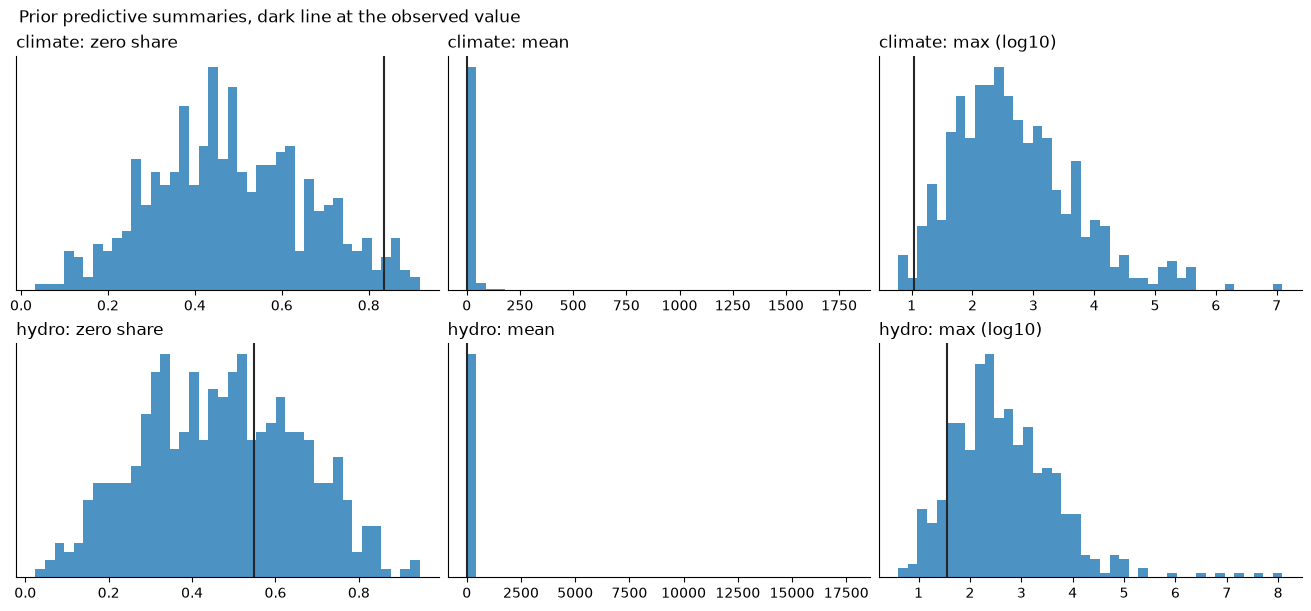

In [5]:
with country_model:
    prior_idata = pm.sample_prior_predictive(draws=500, random_seed=SEED)

observed_summaries = observed_count_summaries(counts)
plot_predictive_summaries(count_summaries(prior_idata.prior_predictive["y"]),
                          observed_summaries,
                          CLASSES,
                          "Prior predictive summaries, dark line at the observed value")

## The fit

The draws land in `fits/`, which is gitignored. `sample_or_load` reads the file back when it exists and does not check that the saved draws came from the data now in memory, so a fit outlives any change to the panel or the feature list. Pass `force_resample=True` after one.

In [6]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     random_seed=SEED)

with country_model:
    idata = sample_or_load(fp=str(FIT_DIR / "country_intercept.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta", "alpha", "tau"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.30,0.07,-2.42,-2.18,463.20,641.17,1.02,0.00,0.00
intercept[hydro],-0.67,0.06,-0.77,-0.58,102.80,319.04,1.06,0.01,0.00
"beta[ln_population_density, climate]",-0.19,0.07,-0.30,-0.08,228.68,504.20,1.03,0.01,0.00
"beta[ln_population_density, hydro]",0.16,0.06,0.06,0.24,125.03,258.67,1.05,0.01,0.00
"beta[ln_gdp_pc, climate]",-0.42,0.30,-0.90,0.07,49.19,152.75,1.12,0.04,0.03
"beta[ln_gdp_pc, hydro]",0.49,0.20,0.18,0.82,49.75,164.19,1.11,0.03,0.02
"beta[square_ln_gdp_pc, climate]",0.52,0.30,0.03,0.98,48.08,117.36,1.12,0.04,0.03
"beta[square_ln_gdp_pc, hydro]",-0.62,0.21,-0.97,-0.29,45.99,113.51,1.12,0.03,0.02
"beta[precip_deviation, climate]",-0.39,0.04,-0.45,-0.33,2260.07,1489.82,1.01,0.00,0.00
"beta[precip_deviation, hydro]",0.24,0.01,0.22,0.27,2550.18,1711.96,1.00,0.00,0.00


## Diagnostics

The 398 country offsets join the parameters of notebook 01, less the two zero-inflation shares and plus the two scales. The non-centered form should keep them mixing, and the energy plot is where a funnel would show first.

0 divergences; worst r_hat 1.123; smallest bulk ESS 46 (beta[square_ln_gdp_pc, hydro])


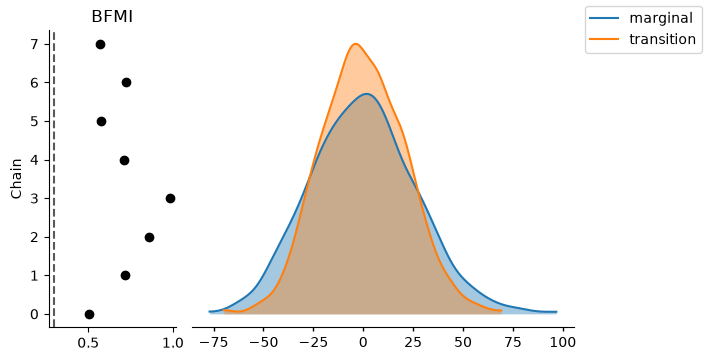

In [7]:
diagnostics = summarize(idata, [*PARAMETERS, "country_offset"])[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

### Where each covariate varies

A country intercept absorbs every difference between countries, so a covariate is identified only by what is left after its country mean is removed. The table splits each standardized covariate's unit variance into the between-country and within-country parts, and the matrix is the correlation of the within-country parts for the three that trend over time.

In [8]:
country_means = scaled[SCALED_FEATURES].groupby(panel["iso"]).transform("mean")
within = scaled[SCALED_FEATURES] - country_means

variance_split = pd.DataFrame({"between": country_means.var(), "within": within.var()})
variance_split.index = FEATURES
variance_split.round(2)

,between,within
ln_population_density,0.97,0.03
ln_gdp_pc,0.95,0.05
square_ln_gdp_pc,0.95,0.05
precip_deviation,0.07,0.93
co2,0.05,0.95
ln_population,0.99,0.01


In [9]:
TRENDING = ["ln_gdp_pc", "square_ln_gdp_pc", "co2"]

within_correlation = within[[f"{name}__standardized" for name in TRENDING]].corr()
within_correlation.index = within_correlation.columns = TRENDING
within_correlation.round(2)

,ln_gdp_pc,square_ln_gdp_pc,co2
ln_gdp_pc,1.00,0.99,0.65
square_ln_gdp_pc,0.99,1.00,0.66
co2,0.65,0.66,1.00


## What the posterior predicts

The same three checks as notebook 01, in the same order. The country plots at the end are where a country term shows its work.

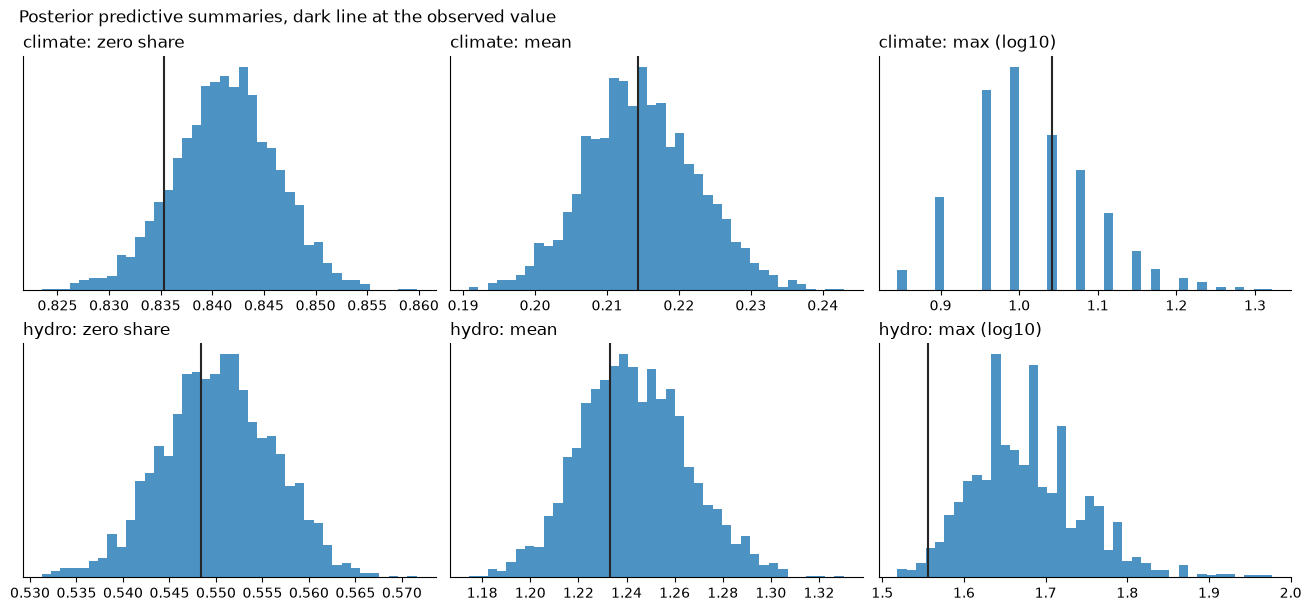

In [10]:
posterior_y = idata.posterior_predictive["y"]
plot_predictive_summaries(count_summaries(posterior_y),
                          observed_summaries,
                          CLASSES,
                          "Posterior predictive summaries, dark line at the observed value")

### The count distribution

A rootogram puts the predicted frequency of each count, with its interval, against the observed frequency as a point, on a square-root axis so that a frequency of 5 and a frequency of 5,000 are both legible. A point inside its interval is a count the model reproduces.

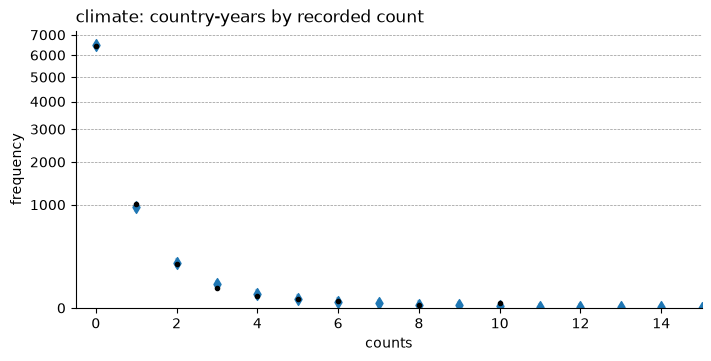

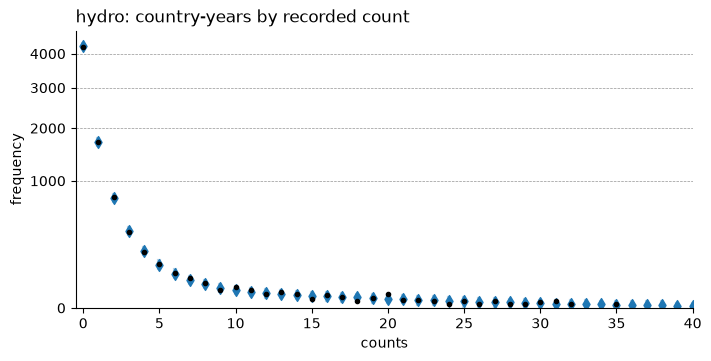

In [11]:
plot_rootograms(idata, counts, CLASSES)

### Interval coverage

Actual coverage minus nominal at every interval width, per country-year on the top row and per country total on the bottom. A calibrated model runs inside the band, which is what uniform draws produce with that many observations. A curve above the band is a predictive that is wider than the data need, and one below is a predictive that is too narrow.

The bottom row is not a fair test once countries have their own intercepts. Each country's total is what its intercept was fit to, so the predictive is centered on it and the only spread left is 43 years of negative binomial noise added up. The row is kept because it says how much of the totals' spread the country term has taken.

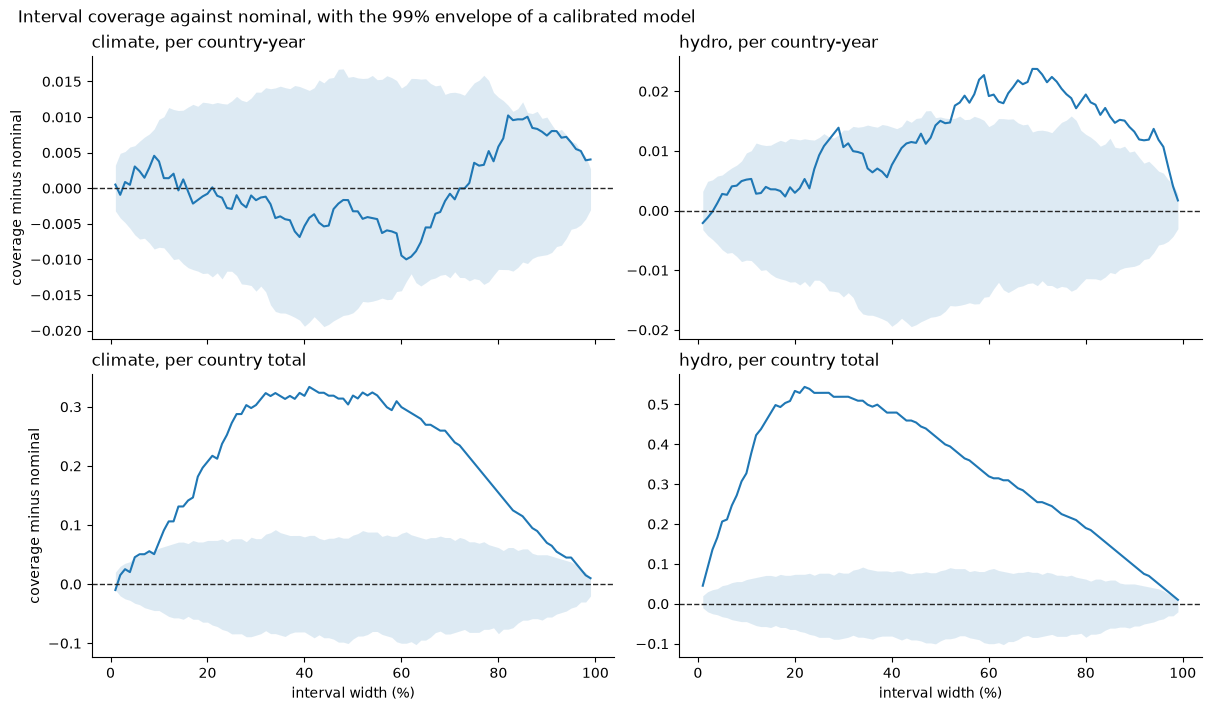

In [12]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

## The country effects

$u_{jc}$ for every country, one forest per class, sorted by posterior mean with 94% intervals. The spread is $\tau_c$ made visible, and the countries at either end are the ones the covariates explain worst.

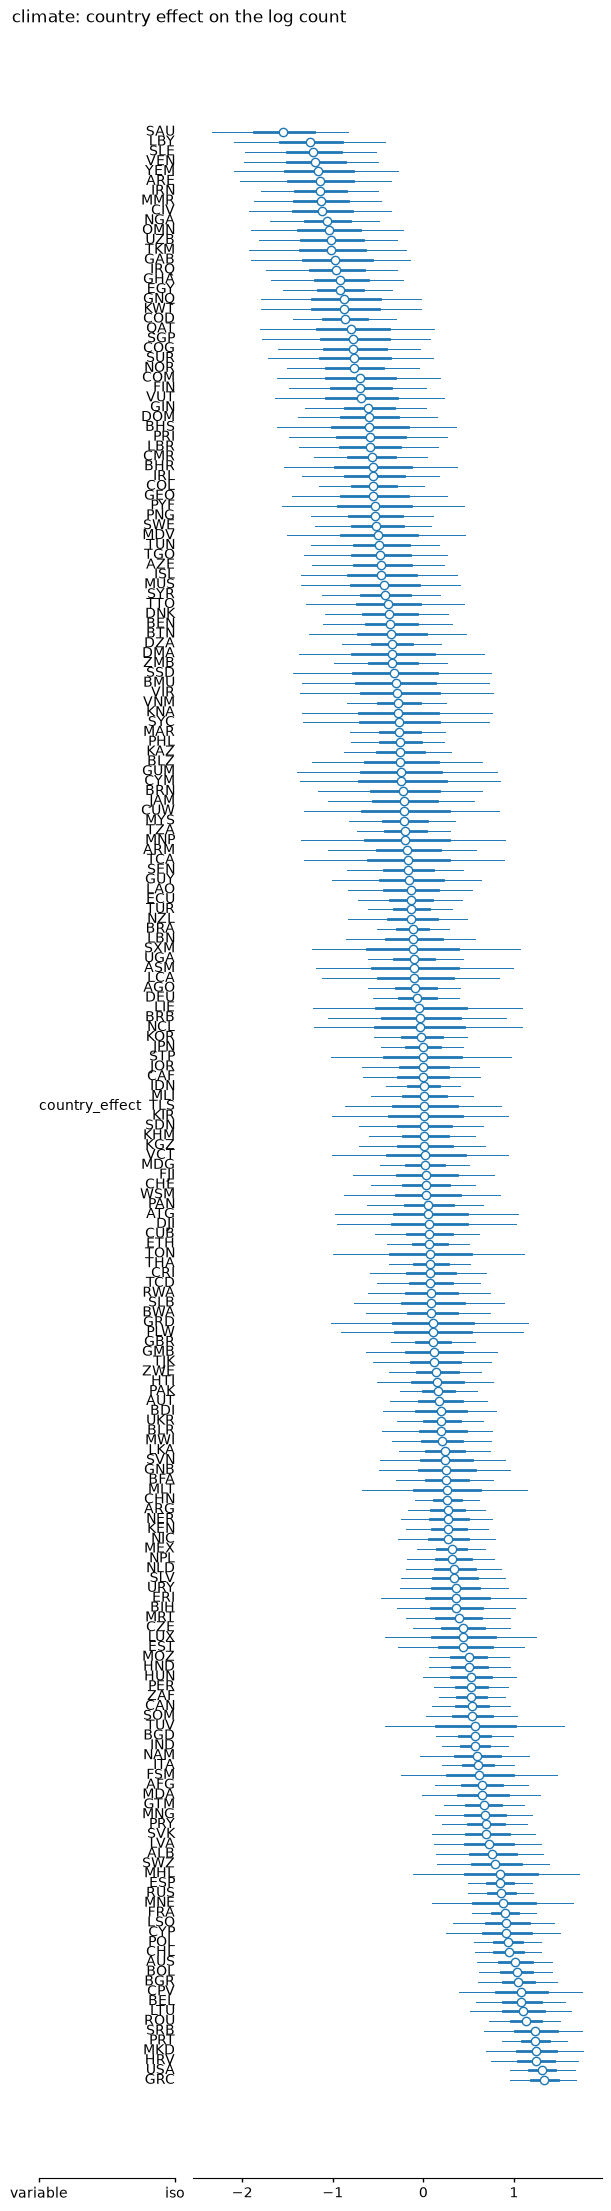

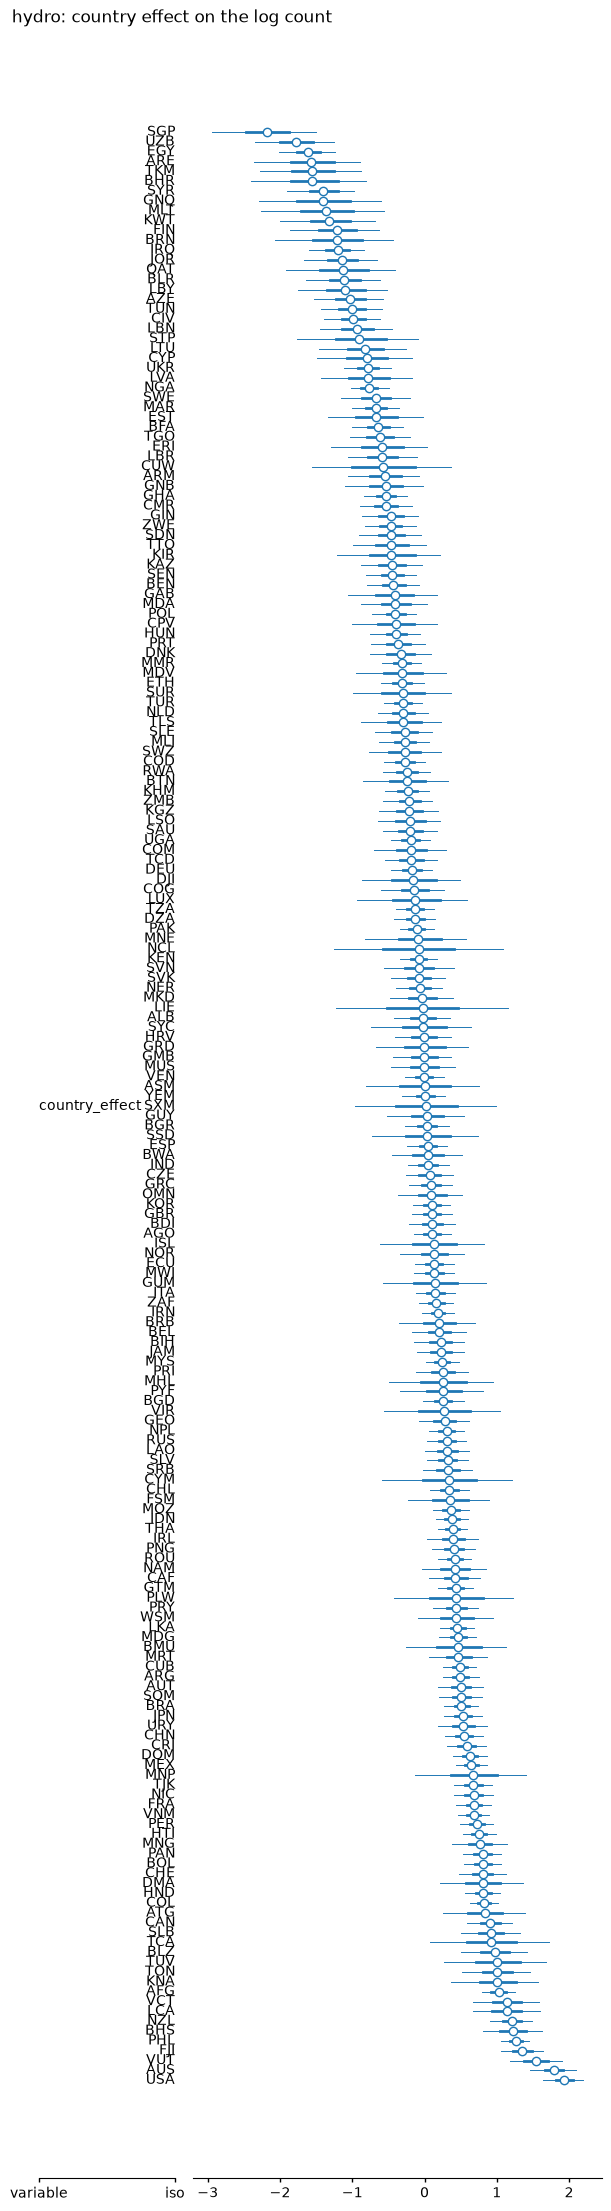

In [13]:
for name in CLASSES:
    order = idata.posterior["country_effect"].sel(disaster=name).mean(dim=["chain", "draw"]).to_series().sort_values()

    grid = plot_forest(idata,
                       var_names="country_effect",
                       coords={"disaster": name, "iso": list(order.index)},
                       combined=True,
                       backend="matplotlib",
                       figure_kwargs={"figsize": (6, 22)})
    grid.viz["figure"].item().suptitle(f"{name}: country effect on the log count", x=0.01, ha="left")

plt.show()

## A few countries over time

The same three countries as notebook 01, with the same layout. The question is whether the decade-long residuals for China and Laos have closed.

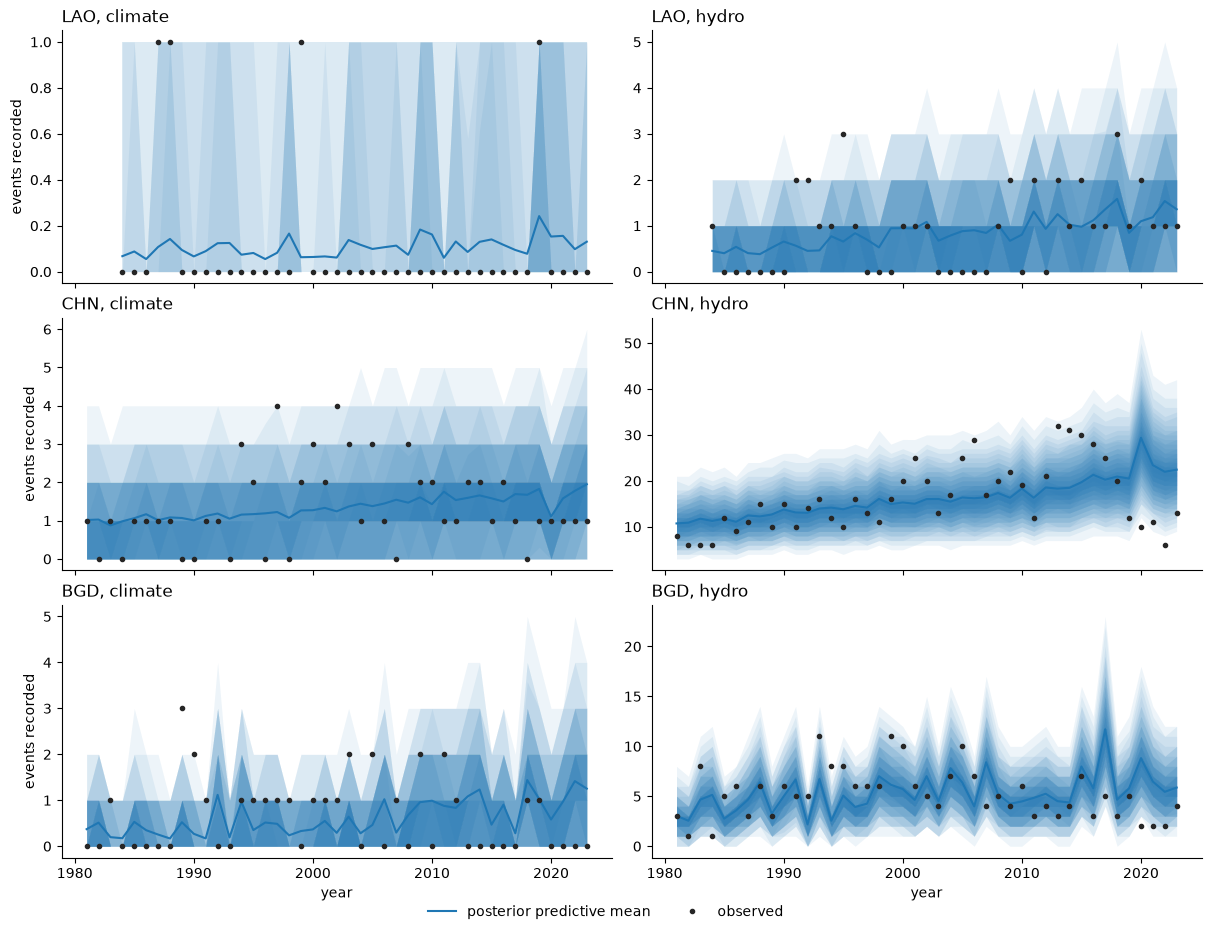

In [14]:
plot_country_counts(posterior_y, panel, counts, ["LAO", "CHN", "BGD"], CLASSES)

## The posterior against the prior

Each panel is the posterior of one parameter in blue over its prior in orange. The covariate coefficients are the ones to compare with notebook 01. A coefficient that moves once countries have their own intercept was partly carrying between-country differences.

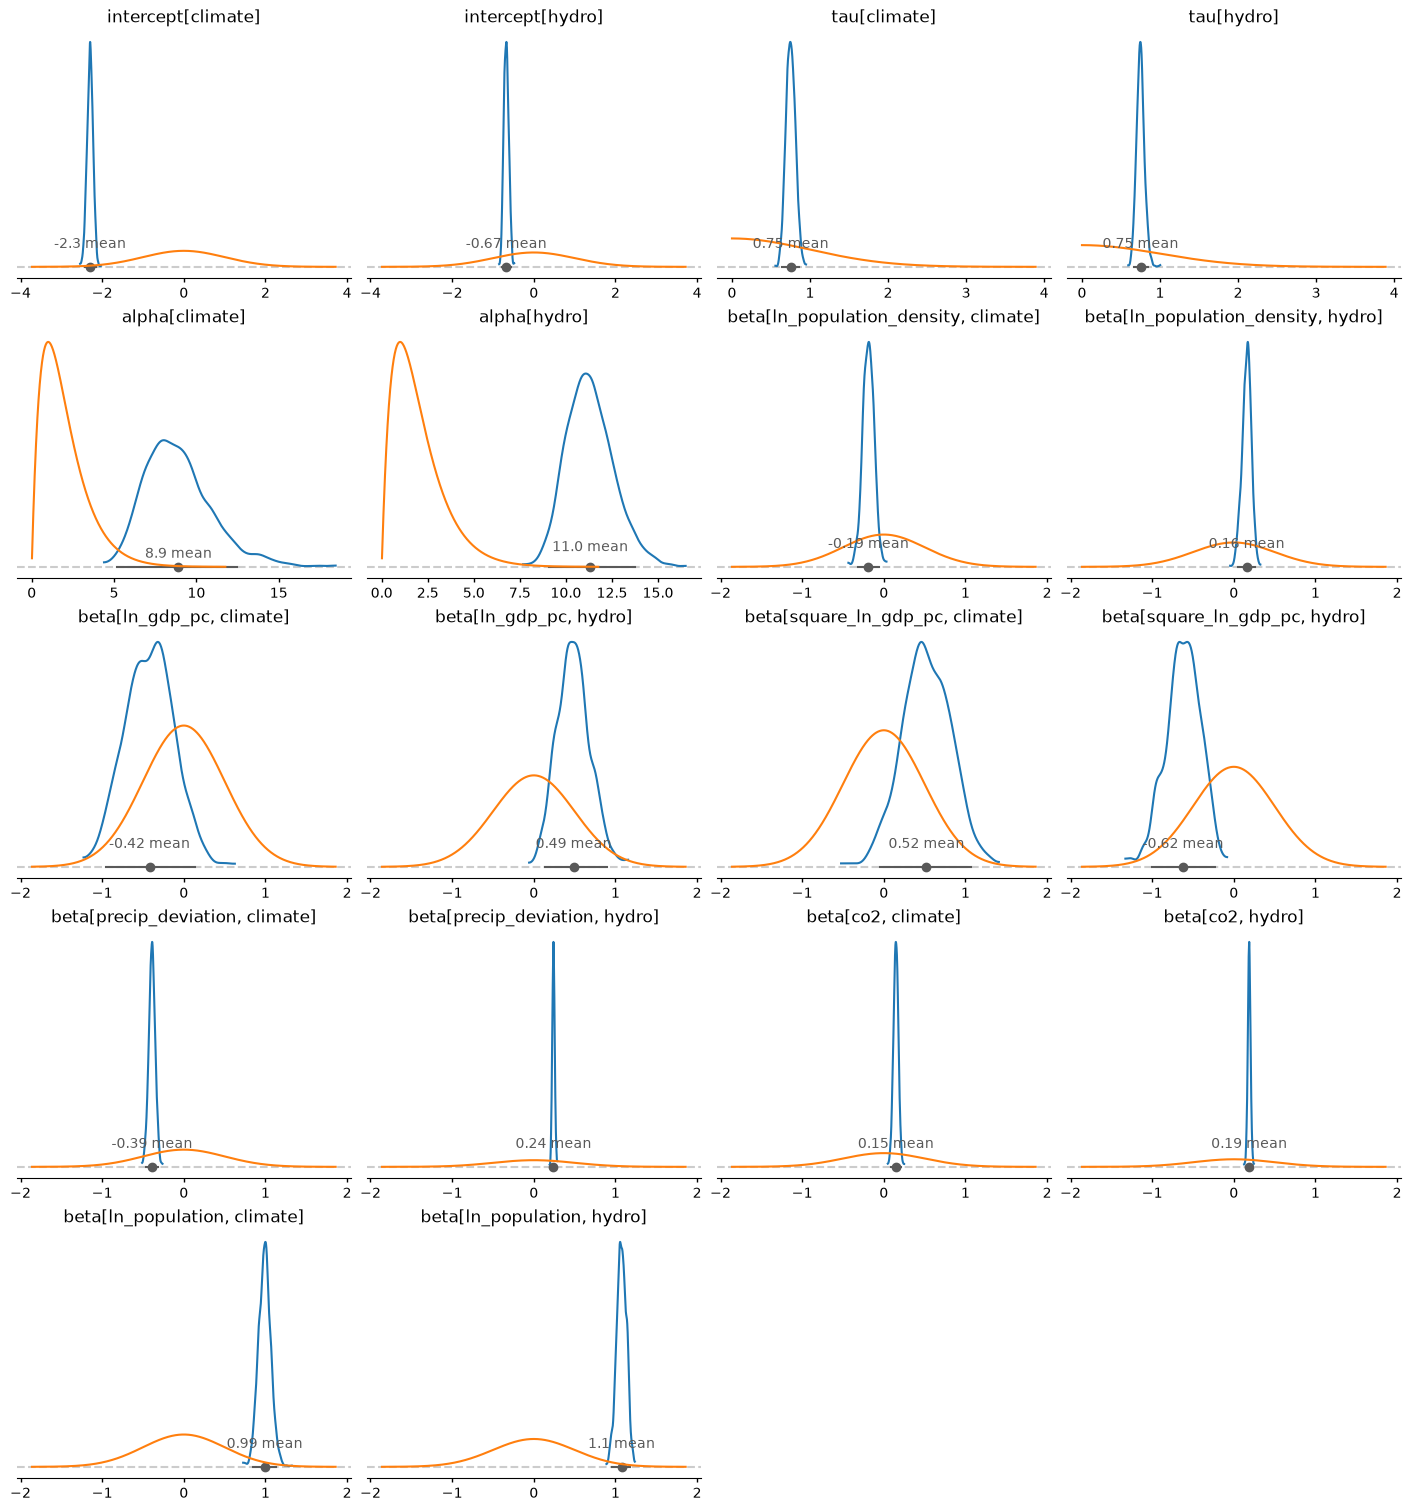

In [15]:
posterior = idata.posterior
of_interest = xr.Dataset({
    **{f"intercept[{name}]": posterior["intercept"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"tau[{name}]": posterior["tau"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"beta[{feature}, {name}]": posterior["beta"].sel(feature=feature, disaster=name, drop=True)
       for feature in FEATURES for name in CLASSES},
})

priors = {
    **{f"intercept[{name}]": pz.Normal(0, 1) for name in CLASSES},
    **{f"tau[{name}]": pz.HalfNormal(1) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
    **{f"beta[{feature}, {name}]": pz.Normal(0, 0.5) for feature in FEATURES for name in CLASSES},
}

fig = plot_posterior_with_prior(of_interest, priors)
plt.show()

## What was learned

*The country term absorbed the overdispersion.* $\tau$ is 0.75 for both classes, so a country one standard deviation out records $e^{0.75}$, about twice, the events of the average one. With that in the model, $\alpha$ rose from 2.5 and 4.6 in notebook 01 to 11 and 9, and sits in the tail of its `Gamma(2, 1)` prior. Most of what the negative binomial was calling extra variance was countries differing from each other.

*The level is fixed and the timing is not.* The country-year coverage is inside the band for climate and 1 to 2 points over for hydro, and the country totals are covered far more than nominal, with the 20% interval holding half of the countries, since each intercept was fit to its own total. The country plots show what the totals cannot. China's predictive mean now runs through the middle of its record, but the intervals are narrow and the record sits above them through the 2010s and below them in the 2020s. A country intercept holds a level. It cannot hold a run of years on one side of it, and with $\alpha$ near 11 the model no longer has the dispersion to cover one.

*GDP per capita is identified by 5% of its variance.* 95% of `ln_gdp_pc` varies between countries, and the intercepts take all of it, so the coefficient is left with within-country growth. Within countries the level and its square correlate at 0.99, and both correlate at 0.65 with `co2`, because all three are slow trends over 1981 to 2023. That is the ESS of 46 and the sign swap against notebook 01, where the hydro coefficient went from -0.38 to +0.49 and the square from +0.07 to -0.62. The quadratic in GDP has no within-country content of its own.

*The mixing is weaker.* No divergences, but r_hat reaches 1.12 and the bulk ESS falls to 46 on the GDP pair, against 1.04 and 219 in notebook 01. The pair is the cause.

*Next.* Split each covariate into its country mean and its within-country deviation, with a coefficient on each. The between coefficient answers whether richer countries record more disasters, the within coefficient whether a country records more as it grows richer, and the intercept sits on top of both. The square of GDP goes. That is notebook 03, and it is the Mundlak decomposition.